In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from collections import defaultdict, Counter
from Bio import Phylo
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches
from matplotlib.font_manager import fontManager

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
fontManager.addfont(font_path)

normal_font = FontProperties(fname=font_path, size=7)
italic_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=10)

plt.rcParams["font.family"] = [FontProperties(fname=font_path).get_name()]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

genus_name = 'Escherichia'
label = 'pident_90'
folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
os.chdir(folder)

tree_file = f"./tree_data/tr_average-typical_chr_by_acc-{label}-normalized_by_size.txt-bootstrap.txt"
link_file = f"{genus_name}_typical_chromosome_sub_replicon_link.csv"
stat_file = "replicon-plasmid_fraction-self_bitscore_statistics.csv"

all_data = pd.read_csv('/active-data/analysis_results/chr_pla/genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
all_data["org_n"] = all_data['species'].apply(extract_genus_name)
org_data = all_data[all_data['genus_clean'].str.contains(genus_name, na=False)].reset_index(drop=True)
category_map = dict(zip(org_data["accession"], org_data["org_n"]))

tree = Phylo.read(tree_file, "newick")
terminals = tree.get_terminals()
target_list = [leaf.name.strip() for leaf in terminals]
n_targets = len(target_list)
target_set = set(target_list)

stat_df = pd.read_csv(stat_file)
stat_map = dict(zip(stat_df["accession"].str.strip(), stat_df.to_dict("records")))

link_df = pd.read_csv(link_file)
source_dict = defaultdict(dict)
source_count = defaultdict(int)
target_count = defaultdict(int)

for _, row in link_df.iterrows():
    s = str(row['source']).strip()
    t = str(row['target']).strip()
    cov = float(row['coverage'])
    if t in target_set:
        source_dict[s][t] = cov
        source_count[s] += 1
        target_count[t] += 1

valid_sources = []
source_frac = {}
for s in source_dict:
    stat = stat_map.get(s)
    if stat is not None:
        frac = stat["average plasmid fraction-pident_90"]
        source_frac[s] = frac
        valid_sources.append(s)

valid_sources.sort(key=lambda x: source_frac[x])
n_sources = len(valid_sources)
source_to_x = {s: i for i, s in enumerate(valid_sources)}
target_to_y = {t: i for i, t in enumerate(target_list)}

In [2]:
from collections import Counter

def get_leaf_category(leaf_node):
    acc = leaf_node.name.strip().split('-')[0]
    return category_map.get(acc, None)

def get_category_from_name(name_str):
    acc = name_str.strip().split('-')[0]
    return category_map.get(acc, None)

leaf_categories = [get_leaf_category(leaf) for leaf in terminals]
cat_count = Counter([c for c in leaf_categories if c])
sorted_cats = [cat for cat, cnt in cat_count.most_common()]
total_valid_cats = len(sorted_cats)

if total_valid_cats > 5:
    top_display = 4
    show_others = True
else:
    top_display = total_valid_cats
    show_others = False
top_cats = sorted_cats[:top_display]

custom_colors = [ 
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#00A86B", "#bcbd22", "#17becf",
    "#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#98D8C8",
    "#F7DC6F", "#BB8FCE", "#85C1E9", "#F8C471", "#52B788"
]
colors = custom_colors[:top_display]

cat2color = {cat: colors[i] for i, cat in enumerate(top_cats)}
other_color = "#999997"
unique_cats = top_cats

def get_cat_color(name_str):
    if pd.isna(name_str) or name_str is None:
        return other_color
    acc = name_str.strip().split('-')[0]
    cat = category_map.get(acc, None)
    return cat2color.get(cat, other_color)

target_cats = [get_category_from_name(t) for t in target_list]
source_cats = [get_category_from_name(s) for s in valid_sources]

def get_leaf_categories(node):
    if node.is_terminal():
        acc = node.name.strip().split('-')[0]
        return [category_map.get(acc, None)]
    cats = []
    for child in node.clades:
        cats.extend(get_leaf_categories(child))
    return cats

def annotate_node_category(node):
    cats = get_leaf_categories(node)
    valid = [c for c in cats if c is not None]
    if len(set(valid)) == 1 and len(valid) > 0:
        node.clade_category = valid[0]
    else:
        node.clade_category = None
    for child in node.clades:
        annotate_node_category(child)

annotate_node_category(tree.root)

norm = Normalize(vmin=0, vmax=1)
plasmidness_cmap = LinearSegmentedColormap.from_list(
    "plasmidness_blue_yellow", ["#ff7f0e", '#a5d6a5', "#cce7ff"]
)

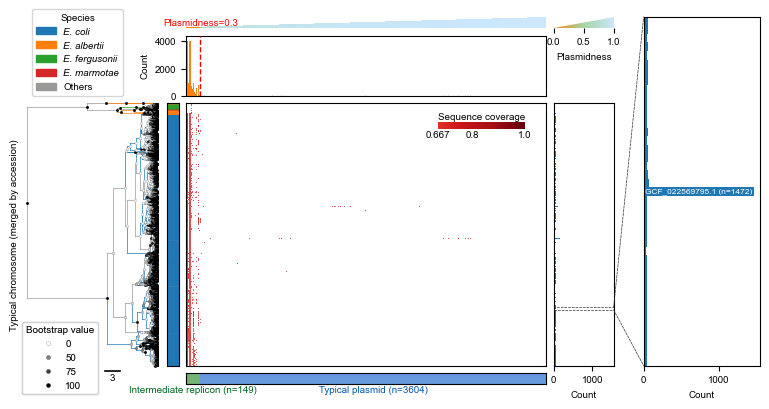

In [3]:
figsize = (7.5, 7.5)

space_width = 0.01
color_bar_width = 0.015
heat_map_width = 0.48
heat_map_height = 0.35
count_width = 0.08
tree_width = 0.2
tree_add_height_fraction = 0.05

fig = plt.figure(figsize=figsize)

ax_tree        = fig.add_axes([0.02, 1-color_bar_width-space_width-count_width-space_width-heat_map_height-tree_add_height_fraction*heat_map_height, 
                               tree_width-0.02, heat_map_height+tree_add_height_fraction*heat_map_height*2])
ax_color_band  = fig.add_axes([tree_width+space_width, 1-color_bar_width-space_width-count_width-space_width-heat_map_height, 
                               color_bar_width, heat_map_height])
ax_main        = fig.add_axes([tree_width+space_width+color_bar_width+space_width, 1-color_bar_width-space_width-count_width-space_width-heat_map_height,
                               heat_map_width, heat_map_height])
ax_top_bar     = fig.add_axes([tree_width+space_width+color_bar_width+space_width, 1-color_bar_width-space_width-count_width, 
                               heat_map_width, count_width])
ax_frac_bar    = fig.add_axes([tree_width+space_width+color_bar_width+space_width, 1-color_bar_width, heat_map_width, color_bar_width])
ax_source_cat  = fig.add_axes([tree_width+space_width+color_bar_width+space_width, 1-color_bar_width-space_width-count_width-space_width-heat_map_height-space_width-color_bar_width, 
                               heat_map_width, color_bar_width])
ax_right_bar   = fig.add_axes([tree_width+space_width+color_bar_width+space_width+heat_map_width+space_width, 1-color_bar_width-space_width-count_width-space_width-heat_map_height,
                               count_width, heat_map_height])
ax_cbar        = fig.add_axes([tree_width+space_width+color_bar_width+space_width+heat_map_width+space_width, 1-color_bar_width, 
                               count_width, color_bar_width])

leaf_y = {leaf: i for i, leaf in enumerate(terminals)}

def assign_y(node):
    if node.is_terminal():
        node.y = leaf_y[node]
        return node.y
    cy = [assign_y(c) for c in node.clades]
    node.y = np.mean(cy)
    return node.y

def assign_x(node, curr_x=0):
    bl = node.branch_length or 0
    node.x = curr_x + bl
    for c in node.clades:
        assign_x(c, curr_x + bl)

assign_y(tree.root)
assign_x(tree.root, curr_x=0)
max_x = max(leaf.x for leaf in terminals)

def draw_node(node):
    col = cat2color.get(node.clade_category, other_color)
    for c in node.clades:
        c_col = cat2color.get(c.clade_category, other_color)
        ax_tree.plot([node.x, node.x], [node.y, c.y], lw=0.5, color=c_col)
        ax_tree.plot([node.x, c.x], [c.y, c.y], lw=0.5, color=c_col)
        draw_node(c)

draw_node(tree.root)

def draw_bs(node):
    if node.confidence is not None:
        bs = np.clip(node.confidence, 0, 100)
        g = int((1 - bs/100)*255)
        ax_tree.scatter(node.x, node.y, s=4, c=f'#{g:02x}{g:02x}{g:02x}',
                        edgecolor='k', lw=0.1, zorder=5)
    for c in node.clades:
        draw_bs(c)

draw_bs(tree.root)

ax_tree.set_ylim(-0.5-n_targets*tree_add_height_fraction, n_targets - 0.5+n_targets*tree_add_height_fraction)
ax_tree.set_xlim(-max_x*0.02, max_x*1.02)
ax_tree.axis('off')
ax_tree.text(-max_x*0.1, n_targets/2, 'Typical chromosome (merged by accession)', ha='center', va='center', fontsize=7, rotation=90)

scale_bar_len = 3
sx0 = max_x * 0.6
sx1 = sx0 + scale_bar_len
sy  = n_targets*(-0.02)
ax_tree.plot([sx0, sx1], [sy, sy], c="black", lw=1.2)
ax_tree.text((sx0+sx1)/2, sy-n_targets*0.01, "3", ha="center", va="top", fontsize=7, fontproperties=normal_font)

for y, t in enumerate(target_list):
    color = get_cat_color(t)
    ax_color_band.fill_between([0,1], y-0.5, y+0.5, color=color)
ax_color_band.set_xlim(0,1)
ax_color_band.set_ylim(-0.5, n_targets-0.5)
ax_color_band.set_xticks([])
ax_color_band.set_yticks([])

for s in valid_sources:
    x = source_to_x[s]
    for t, cov in source_dict[s].items():
        y = target_to_y[t]
        g = int(220 - 170 * cov)
        b = int(220 - 170 * cov)
        ax_main.add_patch(Rectangle((x-0.5, y-0.5), 1,1, color=f'#dc{g:02x}{b:02x}', lw=0))

ax_main.set_xlim(-0.5, n_sources-0.5)
ax_main.set_ylim(-0.5, n_targets-0.5)
ax_main.set_xticks([])
ax_main.set_yticks([])

norm = plt.Normalize(0, 1)

for i, s in enumerate(valid_sources):
    frac_val = source_frac[s]
    color = plasmidness_cmap(norm(frac_val))
    if n_sources > 1:
        frac = i / (n_sources - 1)
    else:
        frac = 1.0
    height = 0.1 + frac * 0.9
    rect = Rectangle((i, 0), 1, height, color=color, lw=0)
    ax_frac_bar.add_patch(rect)

ax_frac_bar.set_xlim(-0.5, n_sources - 0.5)
ax_frac_bar.set_ylim(0, 1)
ax_frac_bar.set_xticks([])
ax_frac_bar.set_yticks([])
ax_frac_bar.spines[:].set_visible(False)

xs = np.arange(n_sources)
hs = [source_count[s] for s in valid_sources]
cs = [plasmidness_cmap(norm(source_frac[s])) for s in valid_sources]
ax_top_bar.bar(xs, hs, color=cs, width=1)
ax_top_bar.set_xlim(-0.5, n_sources-0.5)
ax_top_bar.set_xticks([])
ax_top_bar.set_ylabel('Count', fontproperties=normal_font)

threshold_val = 0.3
frac_values = [source_frac[s] for s in valid_sources]
x_threshold = None
for i, val in enumerate(frac_values):
    if val >= threshold_val:
        x_threshold = i - 0.5
        break
if x_threshold is None:
    x_threshold = len(frac_values) - 0.5

ax_top_bar.axvline(x=x_threshold, color='red', linestyle='--', linewidth=1, zorder=10)
ax_frac_bar.text(x=x_threshold, y=0.5, s='Plasmidness=0.3', color='red', fontsize=7, va='center', ha='center', zorder=10)

color_trans = "#73b373"
color_plas  = "#6699dd"
threshold_idx = x_threshold

ax_source_cat.add_patch(Rectangle((-0.5, 0), threshold_idx+0.5, 1, color=color_trans))
ax_source_cat.add_patch(Rectangle((threshold_idx, 0), n_sources - threshold_idx, 1, color=color_plas))

ax_source_cat.set_xlim(-0.5, n_sources - 0.5)
ax_source_cat.set_ylim(0, 1)
ax_source_cat.set_xticks([])
ax_source_cat.set_yticks([])

n_trans = int(threshold_idx + 0.5)
n_plas = n_sources - n_trans
ax_source_cat.text(threshold_idx/2, -0.1, f"Intermediate replicon (n={n_trans})", ha='center', va='top', fontsize=7, color="#006622")
ax_source_cat.text(threshold_idx + (n_sources-threshold_idx)/2, -0.1, f"Typical plasmid (n={n_plas})", ha='center', va='top', fontsize=7, color="#0056b0")

ys = np.arange(n_targets)
ws = [target_count[t] for t in target_list]
cs = [get_cat_color(t) for t in target_list]
ax_right_bar.barh(ys, ws, color=cs, height=1)
ax_right_bar.set_ylim(-0.5, n_targets-0.5)
ax_right_bar.set_yticks([])
ax_right_bar.set_xlabel('Count', fontproperties=normal_font)

ws_arr = np.array(ws)
cs_arr_r = np.array(cs, dtype=object)
max_idx = np.argmax(ws_arr)
r1 = max(0, max_idx - 20)
r2 = min(n_targets, max_idx + 1 + 20)
xmin_r, xmax_r = ax_right_bar.get_xlim()

right_rect = Rectangle((xmin_r, r1-0.5), xmax_r-xmin_r, r2-r1,
                       facecolor='none', edgecolor='#333333', lw=0.5, linestyle='--', zorder=10)
ax_right_bar.add_patch(right_rect)

add_width = tree_width+space_width+color_bar_width+space_width+heat_map_width+space_width+count_width+space_width+0.03
ax_zoom_right = fig.add_axes([add_width, 1-color_bar_width-space_width-count_width-space_width-heat_map_height, 
                              1-add_width, 1-(1-color_bar_width-space_width-count_width-space_width-heat_map_height)])
ax_zoom_right.barh(np.arange(r2-r1), ws_arr[r1:r2], color=cs_arr_r[r1:r2], height=1)
ax_zoom_right.set_yticks([])
ax_zoom_right.set_xlabel('Count', fontproperties=normal_font)
ax_zoom_right.set_ylim(-0.5, (r2 - r1) - 0.5)

zoom_y = max_idx - r1
max_name = target_list[max_idx].split('-')[0]
ax_zoom_right.text(
    ws_arr[max_idx]/2,
    zoom_y,
    f'{max_name} (n={ws_arr[max_idx]})',
    ha='center', va='center', fontsize=6, color='white', fontproperties=normal_font
)

con3 = ConnectionPatch(
    xyA=(xmax_r, r2-0.5), coordsA=ax_right_bar.transData,
    xyB=(0, 1), coordsB=ax_zoom_right.transAxes,
    axesA=ax_right_bar, axesB=ax_zoom_right,
    color='#333333', linestyle='--', lw=0.5, zorder=10
)
con4 = ConnectionPatch(
    xyA=(xmax_r, r1-0.5), coordsA=ax_right_bar.transData,
    xyB=(0, 0), coordsB=ax_zoom_right.transAxes,
    axesA=ax_right_bar, axesB=ax_zoom_right,
    color='#333333', linestyle='--', lw=0.5, zorder=10
)
fig.patches.extend([con3, con4])

ax_cbar.set_xlim(0, 1)
ax_cbar.set_ylim(0, 1)
triangle = np.array([[0, 0], [1, 0], [1, 1]])
tri = mpatches.Polygon(triangle, facecolor='none', edgecolor='none')
ax_cbar.add_patch(tri)
gradient = np.linspace(0, 1, 256).reshape(1, -1)
im = ax_cbar.imshow(gradient, cmap=plasmidness_cmap, aspect='auto', extent=[0,1,0,1], zorder=1, alpha=1)
im.set_clip_path(tri)
ax_cbar.set_xlabel('Plasmidness', fontsize=7)
ax_cbar.spines[['top', 'bottom', 'right', 'left']].set_visible(False)
ax_cbar.set_yticks([])

genus_abbr = f"{genus_name[0]}."
species_handles = []

for cat in top_cats:
    color = cat2color[cat]
    if cat.startswith(genus_name):
        sp_part = cat.replace(genus_name, "").strip()
        label = f"{genus_abbr} {sp_part}"
    else:
        label = cat
    species_handles.append(mpatches.Patch(color=color, label=label))

if show_others:
    species_handles.append(mpatches.Patch(color=other_color, label="Others"))

species_legend = fig.legend(
    handles=species_handles,
    title="Species",
    title_fontproperties=normal_font,
    prop=italic_font,
    bbox_to_anchor=(0.03, 1.01),
    loc="upper left",
    frameon=True,
    borderaxespad=0
)

for text in species_legend.get_texts():
    if text.get_text().strip() == "Others":
        text.set_fontproperties(normal_font)
    else:
        text.set_fontproperties(italic_font)

bs_values = [0, 50, 75, 100]
bs_handles = []
bs_labels = []
for bs in bs_values:
    g = int((1 - bs/100)*255)
    color = f"#{g:02x}{g:02x}{g:02x}"
    h = Line2D([0], [0], marker="o", color=color, markerfacecolor=color,
               markeredgecolor="k", markeredgewidth=0.1, markersize=3, linestyle="")
    bs_handles.append(h)
    bs_labels.append(f"{bs}")

boostrap_legend = ax_tree.legend(
    handles=bs_handles,
    labels=bs_labels,
    title="Bootstrap value",
    title_fontproperties=normal_font,
    prop=normal_font,
    loc="lower left",
    bbox_to_anchor=(-0.06, -0.07),
    frameon=True
)
ax_tree.add_artist(boostrap_legend)

ax_cov = ax_main.inset_axes([0.70, 0.90, 0.24, 0.03])
grad_x0, grad_x1 = 0, 1
grad_y0, grad_y1 = 0, 1
gradient = np.linspace(2/3, 1, 100).reshape(1, -1)

ax_cov.imshow(
    gradient,
    extent=[grad_x0, grad_x1, grad_y0, grad_y1],
    cmap=plt.cm.Reds,
    aspect='auto',
    zorder=99,
    vmin=0, vmax=1
)

tick_values = [2/3, 0.8, 1.0]
tick_labels = ['0.667', '0.8', '1.0']
for val, lab in zip(tick_values, tick_labels):
    x = grad_x0 + (val - 2/3) / (1 - 2/3) * (grad_x1 - grad_x0)
    ax_cov.plot([x, x], [grad_y0, grad_y1 - 0.1], color='black', lw=1)
    ax_cov.text(x, grad_y0 - 0.12, lab, ha='center', va='top', fontsize=7, fontproperties=normal_font)

ax_cov.text((grad_x0+grad_x1)/2, grad_y1 + 0.05, 'Sequence coverage', 
            ha='center', va='bottom', fontsize=7, fontproperties=normal_font)

ax_cov.set_xlim(0, 1)
ax_cov.set_ylim(0, 1)
ax_cov.set_xticks([])
ax_cov.set_yticks([])
for spine in ax_cov.spines.values():
    spine.set_visible(False)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig(f"{genus_name}_NMS_MS_link1.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{genus_name}_NMS_MS_link1.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()